
# Project : RAG From Scratch (FAISS + Hybrid Search)
**Domain:** Enterprise Q&A / Document Search | **Level:** Foundation | **Stack:** Python, Sentence-Transformers, FAISS, BM25, Groq (gpt-oss-120b)

## Problem statement
LLMs don't know a company's private documents, and if you just ask them they make up answers. In this project I built a RAG pipeline from scratch: split a company handbook into chunks, turn them into vectors, store them in FAISS, and give only the best chunks to the LLM so it answers from the document.

## What I built
- Recursive chunking with overlap
- Dense search (FAISS, cosine on normalized vectors)
- Keyword search (BM25) and a hybrid of both using Reciprocal Rank Fusion
- Reordering chunks to reduce the "lost in the middle" problem
- A small test set to measure which retrieval method works best
- A test that the bot says "I don't know" for things not in the document

## Step 0: Install libraries

In [2]:
!pip install -q faiss-cpu sentence-transformers langchain-text-splitters rank_bm25 openai pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 76.9 MB/s eta 0:00:00


## Step 1: Connect to Groq
Using the free Groq API. The key is asked once with getpass so it doesn't get saved in the notebook.

In [3]:
import os, json, time, re
from getpass import getpass
from openai import OpenAI

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass("Paste your Groq API key here: ")

client = OpenAI(api_key=os.environ["GROQ_API_KEY"], base_url="https://api.groq.com/openai/v1")
MODEL = "openai/gpt-oss-120b"

def call_llm(prompt, system="You are a helpful assistant.", json_mode=False):
    for attempt in range(3):
        try:
            msgs = [{"role": "system", "content": system}, {"role": "user", "content": prompt}]
            if json_mode:
                res = client.chat.completions.create(model=MODEL, messages=msgs, temperature=0, response_format={"type": "json_object"})
            else:
                res = client.chat.completions.create(model=MODEL, messages=msgs, temperature=0)
            return (res.choices[0].message.content or "").strip()
        except Exception as e:
            print("LLM error (try", attempt + 1, "):", str(e)[:150])
            time.sleep(6)
    return ""

print(call_llm("Say hello in 5 words"))

Paste your Groq API key here: ··········
Hello there, nice to meet!


## Step 2: Load the document
I wrote a small fake company handbook (Northwind Tech) so anyone can run this without downloading files. You can replace `handbook_text` with your own text or PDF text.

In [4]:
handbook_text = '''NORTHWIND TECH - EMPLOYEE HANDBOOK

1. Leave Policy
Every full-time employee gets 24 days of paid annual leave per year. Up to 5 unused days can be carried over to the next year, anything more than that expires on 31 March. Sick leave is separate and gives 10 days per year. If you want to take more than 3 days off in a row, please tell your manager at least 2 weeks before.

2. Remote and Hybrid Work
Northwind follows a hybrid model. Employees come to the office on Tuesday, Wednesday and Thursday and can work from home on Monday and Friday. Fully remote work needs written approval from a VP. New joiners get a one-time home office allowance of Rs 15000 to buy a desk, chair or monitor.

3. Expense Claims
Submit all expense claims within 30 days of spending the money, otherwise the claim is rejected. Receipts are needed for any expense above Rs 500. Meals during travel are reimbursed up to Rs 1200 per day. Claims above Rs 10000 need approval from a director along with the manager.

4. Business Travel
Flights under 6 hours must be booked in economy class. Hotels are capped at Rs 6000 per night in metro cities and Rs 4000 per night elsewhere. Travel must be booked through the company travel portal at least 7 days ahead.

5. Information Security
Passwords must be at least 14 characters long and multi-factor authentication is mandatory on all company accounts. All laptops use full disk encryption. Any security incident, like a phishing click or a lost device, must be reported to the security team within 2 hours. Never share customer data on personal email or chat apps.

6. Onboarding and Probation
Every new joiner gets a 90 day onboarding plan and a buddy from the same team. The probation period is 6 months. The notice period is 30 days during probation and 60 days after probation is confirmed.

7. Performance Reviews
Performance reviews happen twice a year, in June and in December. Ratings go from 1 to 5. Employees who score 4 or above are eligible for the yearly bonus and are considered first for promotions.

8. Benefits and Learning
Health insurance covers the employee, spouse and children with a cover of Rs 5 lakh per family. Each employee also gets a learning budget of Rs 40000 per year for courses, books and certifications. Unused learning budget does not carry over.

9. Equipment
Laptops are replaced every 3 years. If a laptop is damaged or lost, raise a ticket with IT on the same day. Personal devices cannot be used to store company code.'''

print("characters in document:", len(handbook_text))

characters in document: 2482


## Step 3: Chunking
Splitting the text into small pieces. Overlap of 60 characters so a sentence cut at the edge still shows up in the next chunk.

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=350, chunk_overlap=60, separators=["\n\n", "\n", ". ", " ", ""])
chunks = splitter.split_text(handbook_text)

print("total chunks:", len(chunks))
print("\nfirst chunk:\n", chunks[0])
print("\nsecond chunk:\n", chunks[1])

total chunks: 11

first chunk:
 NORTHWIND TECH - EMPLOYEE HANDBOOK

second chunk:
 1. Leave Policy
Every full-time employee gets 24 days of paid annual leave per year. Up to 5 unused days can be carried over to the next year, anything more than that expires on 31 March. Sick leave is separate and gives 10 days per year. If you want to take more than 3 days off in a row, please tell your manager at least 2 weeks before.


## Step 4: Embeddings + FAISS index
Each chunk becomes a vector (384 numbers). I normalize them so inner product = cosine similarity, and use `IndexFlatIP`.

In [6]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")
chunk_vecs = embed_model.encode(chunks, normalize_embeddings=True)
chunk_vecs = np.array(chunk_vecs, dtype="float32")

dim = chunk_vecs.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(chunk_vecs)

print("vector size:", dim)
print("vectors in index:", index.ntotal)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

vector size: 384
vectors in index: 11


## Step 5: Three ways to search
1. **Dense** - meaning based (FAISS)
2. **BM25** - keyword based
3. **Hybrid** - combine both ranks with Reciprocal Rank Fusion (RRF)

Dense search can miss exact words like numbers and names, BM25 can miss meaning. Hybrid tries to fix both.

In [7]:
from rank_bm25 import BM25Okapi

tokenized_chunks = [c.lower().split() for c in chunks]
bm25 = BM25Okapi(tokenized_chunks)

def dense_search(q, k=4):
    qv = np.array(embed_model.encode([q], normalize_embeddings=True), dtype="float32")
    scores, ids = index.search(qv, k)
    return [int(i) for i in ids[0] if i != -1]

def bm25_search(q, k=4):
    scores = bm25.get_scores(q.lower().split())
    top = np.argsort(scores)[::-1][:k]
    return [int(i) for i in top]

def hybrid_search(q, k=4):
    rrf = {}
    for rank, i in enumerate(dense_search(q, 10)):
        rrf[i] = rrf.get(i, 0) + 1 / (60 + rank + 1)
    for rank, i in enumerate(bm25_search(q, 10)):
        rrf[i] = rrf.get(i, 0) + 1 / (60 + rank + 1)
    best = sorted(rrf, key=rrf.get, reverse=True)[:k]
    return best

test_q = "How many days of annual leave do I get?"
print("dense :", dense_search(test_q))
print("bm25  :", bm25_search(test_q))
print("hybrid:", hybrid_search(test_q))
print("\ntop hybrid chunk:\n", chunks[hybrid_search(test_q)[0]])

dense : [1, 3, 7, 2]
bm25  : [1, 3, 7, 9]
hybrid: [1, 3, 7, 2]

top hybrid chunk:
 1. Leave Policy
Every full-time employee gets 24 days of paid annual leave per year. Up to 5 unused days can be carried over to the next year, anything more than that expires on 31 March. Sick leave is separate and gives 10 days per year. If you want to take more than 3 days off in a row, please tell your manager at least 2 weeks before.


## Step 6: Measure which search is better
I made 8 questions and for each one I know a keyword that must be inside the correct chunk. If any of the top-k chunks has that keyword, it counts as a hit. This is basic retrieval evaluation (hit rate @ k).

          method  hit@1 %  hit@2 %  hit@4 %
0  Dense (FAISS)     75.0    100.0    100.0
1           BM25     75.0     87.5    100.0
2   Hybrid (RRF)     62.5    100.0    100.0


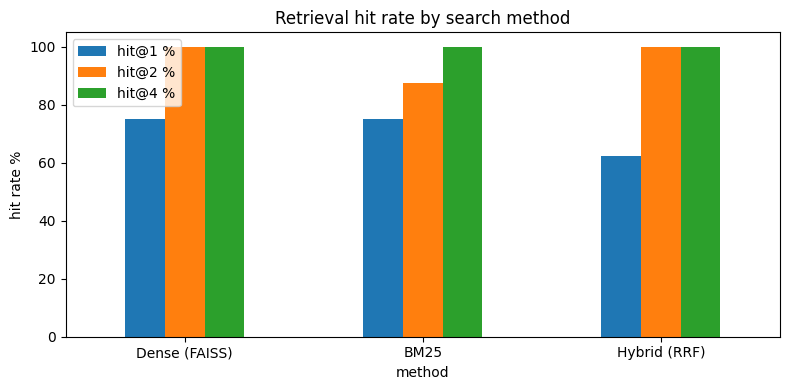

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

test_set = [
    ("How many days of annual leave do I get?", "24 days"),
    ("Which days do I need to come to the office?", "Tuesday"),
    ("What is the hotel limit per night in metro cities?", "Rs 6000"),
    ("How fast should a security incident be reported?", "2 hours"),
    ("What is the notice period after probation?", "60 days"),
    ("How much is the yearly learning budget?", "Rs 40000"),
    ("In which months are performance reviews done?", "June"),
    ("What is the minimum password length?", "14 characters"),
]

def hit_rate(search_fn, k):
    hits = 0
    for question, keyword in test_set:
        ids = search_fn(question, k)
        found = False
        for i in ids:
            if keyword in chunks[i]:
                found = True
        if found:
            hits = hits + 1
    return round(hits / len(test_set) * 100, 1)

rows = []
for name, fn in [("Dense (FAISS)", dense_search), ("BM25", bm25_search), ("Hybrid (RRF)", hybrid_search)]:
    rows.append({"method": name, "hit@1 %": hit_rate(fn, 1), "hit@2 %": hit_rate(fn, 2), "hit@4 %": hit_rate(fn, 4)})

results_df = pd.DataFrame(rows)
print(results_df)

results_df.set_index("method")[["hit@1 %", "hit@2 %", "hit@4 %"]].plot(kind="bar", figsize=(8, 4))
plt.title("Retrieval hit rate by search method")
plt.ylabel("hit rate %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("retrieval_comparison.png")
plt.show()

## Step 7: Full RAG answer
Now the LLM part. Retrieved chunks are reordered so the best ones sit at the start and end of the prompt (LLMs tend to forget the middle). The prompt tells the model to only use the context and say "I don't know" if the answer is not there.

In [9]:
def reorder(top_chunks):
    first = []
    last = []
    for i, c in enumerate(top_chunks):
        if i % 2 == 0:
            first.append(c)
        else:
            last.append(c)
    return first + last[::-1]

def ask(question, k=4):
    ids = hybrid_search(question, k)
    top_chunks = reorder([chunks[i] for i in ids])
    context = "\n\n---\n\n".join(top_chunks)
    system = "You answer questions using only the given context. If the answer is not in the context, reply exactly: I don't know based on the handbook."
    prompt = "CONTEXT:\n" + context + "\n\nQUESTION: " + question + "\nANSWER:"
    return call_llm(prompt, system)

demo_questions = [
    "How many days of annual leave do I get and how many can I carry over?",
    "What is the hotel limit per night and do I need receipts for meals?",
    "What should I do if I lose my laptop?",
]
for q in demo_questions:
    print("Q:", q)
    print("A:", ask(q))
    print()

Q: How many days of annual leave do I get and how many can I carry over?
A: You receive **24 days of paid annual leave each year**, and you can **carry over up to 5 unused days** to the next year.

Q: What is the hotel limit per night and do I need receipts for meals?
A: The hotel limit is **Rs 6,000 per night in metro cities** and **Rs 4,000 per night elsewhere**.  

For meals, a receipt is required **whenever the meal expense exceeds Rs 500** (meals are reimbursed up to Rs 1,200 per day).

Q: What should I do if I lose my laptop?
A: If your laptop is lost, you should raise a ticket with IT on the same day and also report the loss to the security team within 2 hours.



## Step 8: Does it make things up?
These 2 questions are NOT in the handbook. A good RAG bot should say it doesn't know instead of guessing.

In [10]:
out_of_scope = ["What is the CEO's salary?", "Does Northwind give stock options to employees?"]
safe_count = 0
for q in out_of_scope:
    ans = ask(q)
    print("Q:", q)
    print("A:", ans)
    print()
    if "don't know" in ans.lower() or "do not know" in ans.lower():
        safe_count = safe_count + 1

print("refused correctly:", safe_count, "out of", len(out_of_scope))

Q: What is the CEO's salary?
A: I don't know based on the handbook.

Q: Does Northwind give stock options to employees?
A: I don't know based on the handbook.

refused correctly: 2 out of 2


## Step 9: Results summary

In [11]:
best_row = results_df.sort_values("hit@2 %", ascending=False).iloc[0]

print("Chunks made:", len(chunks))
print("Best method at hit@2:", best_row["method"], "with", best_row["hit@2 %"], "%")
print("Out-of-scope questions refused:", safe_count, "/", len(out_of_scope))
print()
print("Resume bullet (from my own run):")
print("Built a RAG pipeline from scratch with FAISS, BM25 hybrid search (RRF) and Groq LLM; tested on", len(test_set), "questions and reached", best_row["hit@2 %"], "% retrieval hit rate @2, and the bot refused", safe_count, "of", len(out_of_scope), "out-of-scope questions instead of guessing.")

Chunks made: 11
Best method at hit@2: Dense (FAISS) with 100.0 %
Out-of-scope questions refused: 2 / 2

Resume bullet (from my own run):
Built a RAG pipeline from scratch with FAISS, BM25 hybrid search (RRF) and Groq LLM; tested on 8 questions and reached 100.0 % retrieval hit rate @2, and the bot refused 2 of 2 out-of-scope questions instead of guessing.


## Key learnings
- Dense search is good with meaning but hybrid search helps when the question has exact terms like numbers or days
- Overlap in chunks matters, otherwise facts get cut in half
- Telling the LLM to say "I don't know" is what stops hallucination, retrieval alone does not
- Always test with a question set, otherwise you are just guessing that it works

## Skills shown
RAG, FAISS, Sentence-Transformers, BM25, Reciprocal Rank Fusion, Chunking, Prompt grounding, Retrieval evaluation (hit rate), Groq API

## Ideas to extend
- Upload a real PDF and use PyMuPDF to read it
- Add a Streamlit chat page
- Use RAGAS to score faithfulness

---
**Built by Akshat Kesharwani** | Portfolio: https://akshatkesharwani-info.github.io/ | GitHub: https://github.com/akshatkesharwani-info

